In [74]:
#Import Pandas, Matplotlib, Numpy, Statsmodels, Seaborn, and Scipy
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
#Import your CSV file into Python as a Pandas dataframe
df = pd.read_csv('C:/Users/rupas/Desktop/Applied Business Statistics/4266261_Rupa_Shrestha_Assignment-2/dataset/Students Performance .csv')

#Print the top five rows and data types for each variable
print(df.head())

#Datatypes for each variable
print(df.dtypes)

  Student_ID  Student_Age     Sex High_School_Type Scholarship  \
0   STUDENT1           19    Male            Other         50%   
1   STUDENT2           22    Male            Other         50%   
2   STUDENT3           19    Male            State         50%   
3   STUDENT4           18  Female          Private         50%   
4   STUDENT5           20    Male          Private         50%   

  Additional_Work  Sports_activity Transportation  Weekly_Study_Hours  \
0             Yes                0        Private                   0   
1             Yes                0        Private                   0   
2              No                0        Private                   2   
3             Yes                0            Bus                   2   
4              No                0            Bus                  12   

  Attendance  Reading  Notes  Listening_in_Class  Project_work  Grade  
0     Always        1      1                   0             0    4.0  
1     Always        

In [76]:
#display the summary statistics
df.describe()

,Student_Age,Sports_activity,Weekly_Study_Hours,Reading,Notes,Listening_in_Class,Project_work,Grade
count,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000,145.000000
mean,19.531034,0.400000,2.331034,0.475862,0.537931,0.517241,0.496552,2.534483
std,1.775822,0.491596,4.249273,0.501148,0.500287,0.501435,0.501721,1.341971
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,19.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,3.000000
75%,21.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,3.500000
max,24.000000,1.000000,12.000000,1.000000,1.000000,1.000000,1.000000,4.000000


In [77]:
#converting categorical to numeric data
df['Scholarship'] = df['Scholarship'].str.replace('%', '', regex=False)
df['Scholarship'] = pd.to_numeric(df['Scholarship'])
df['Scholarship'] = df['Scholarship']/100

attendance_mapping = {
    'Always': 1,
    'Sometimes': 0.5,
    'Never': 0
}
df['Attendance'] = df['Attendance'].replace(attendance_mapping)
df['Attendance'] = pd.to_numeric(df['Attendance'])

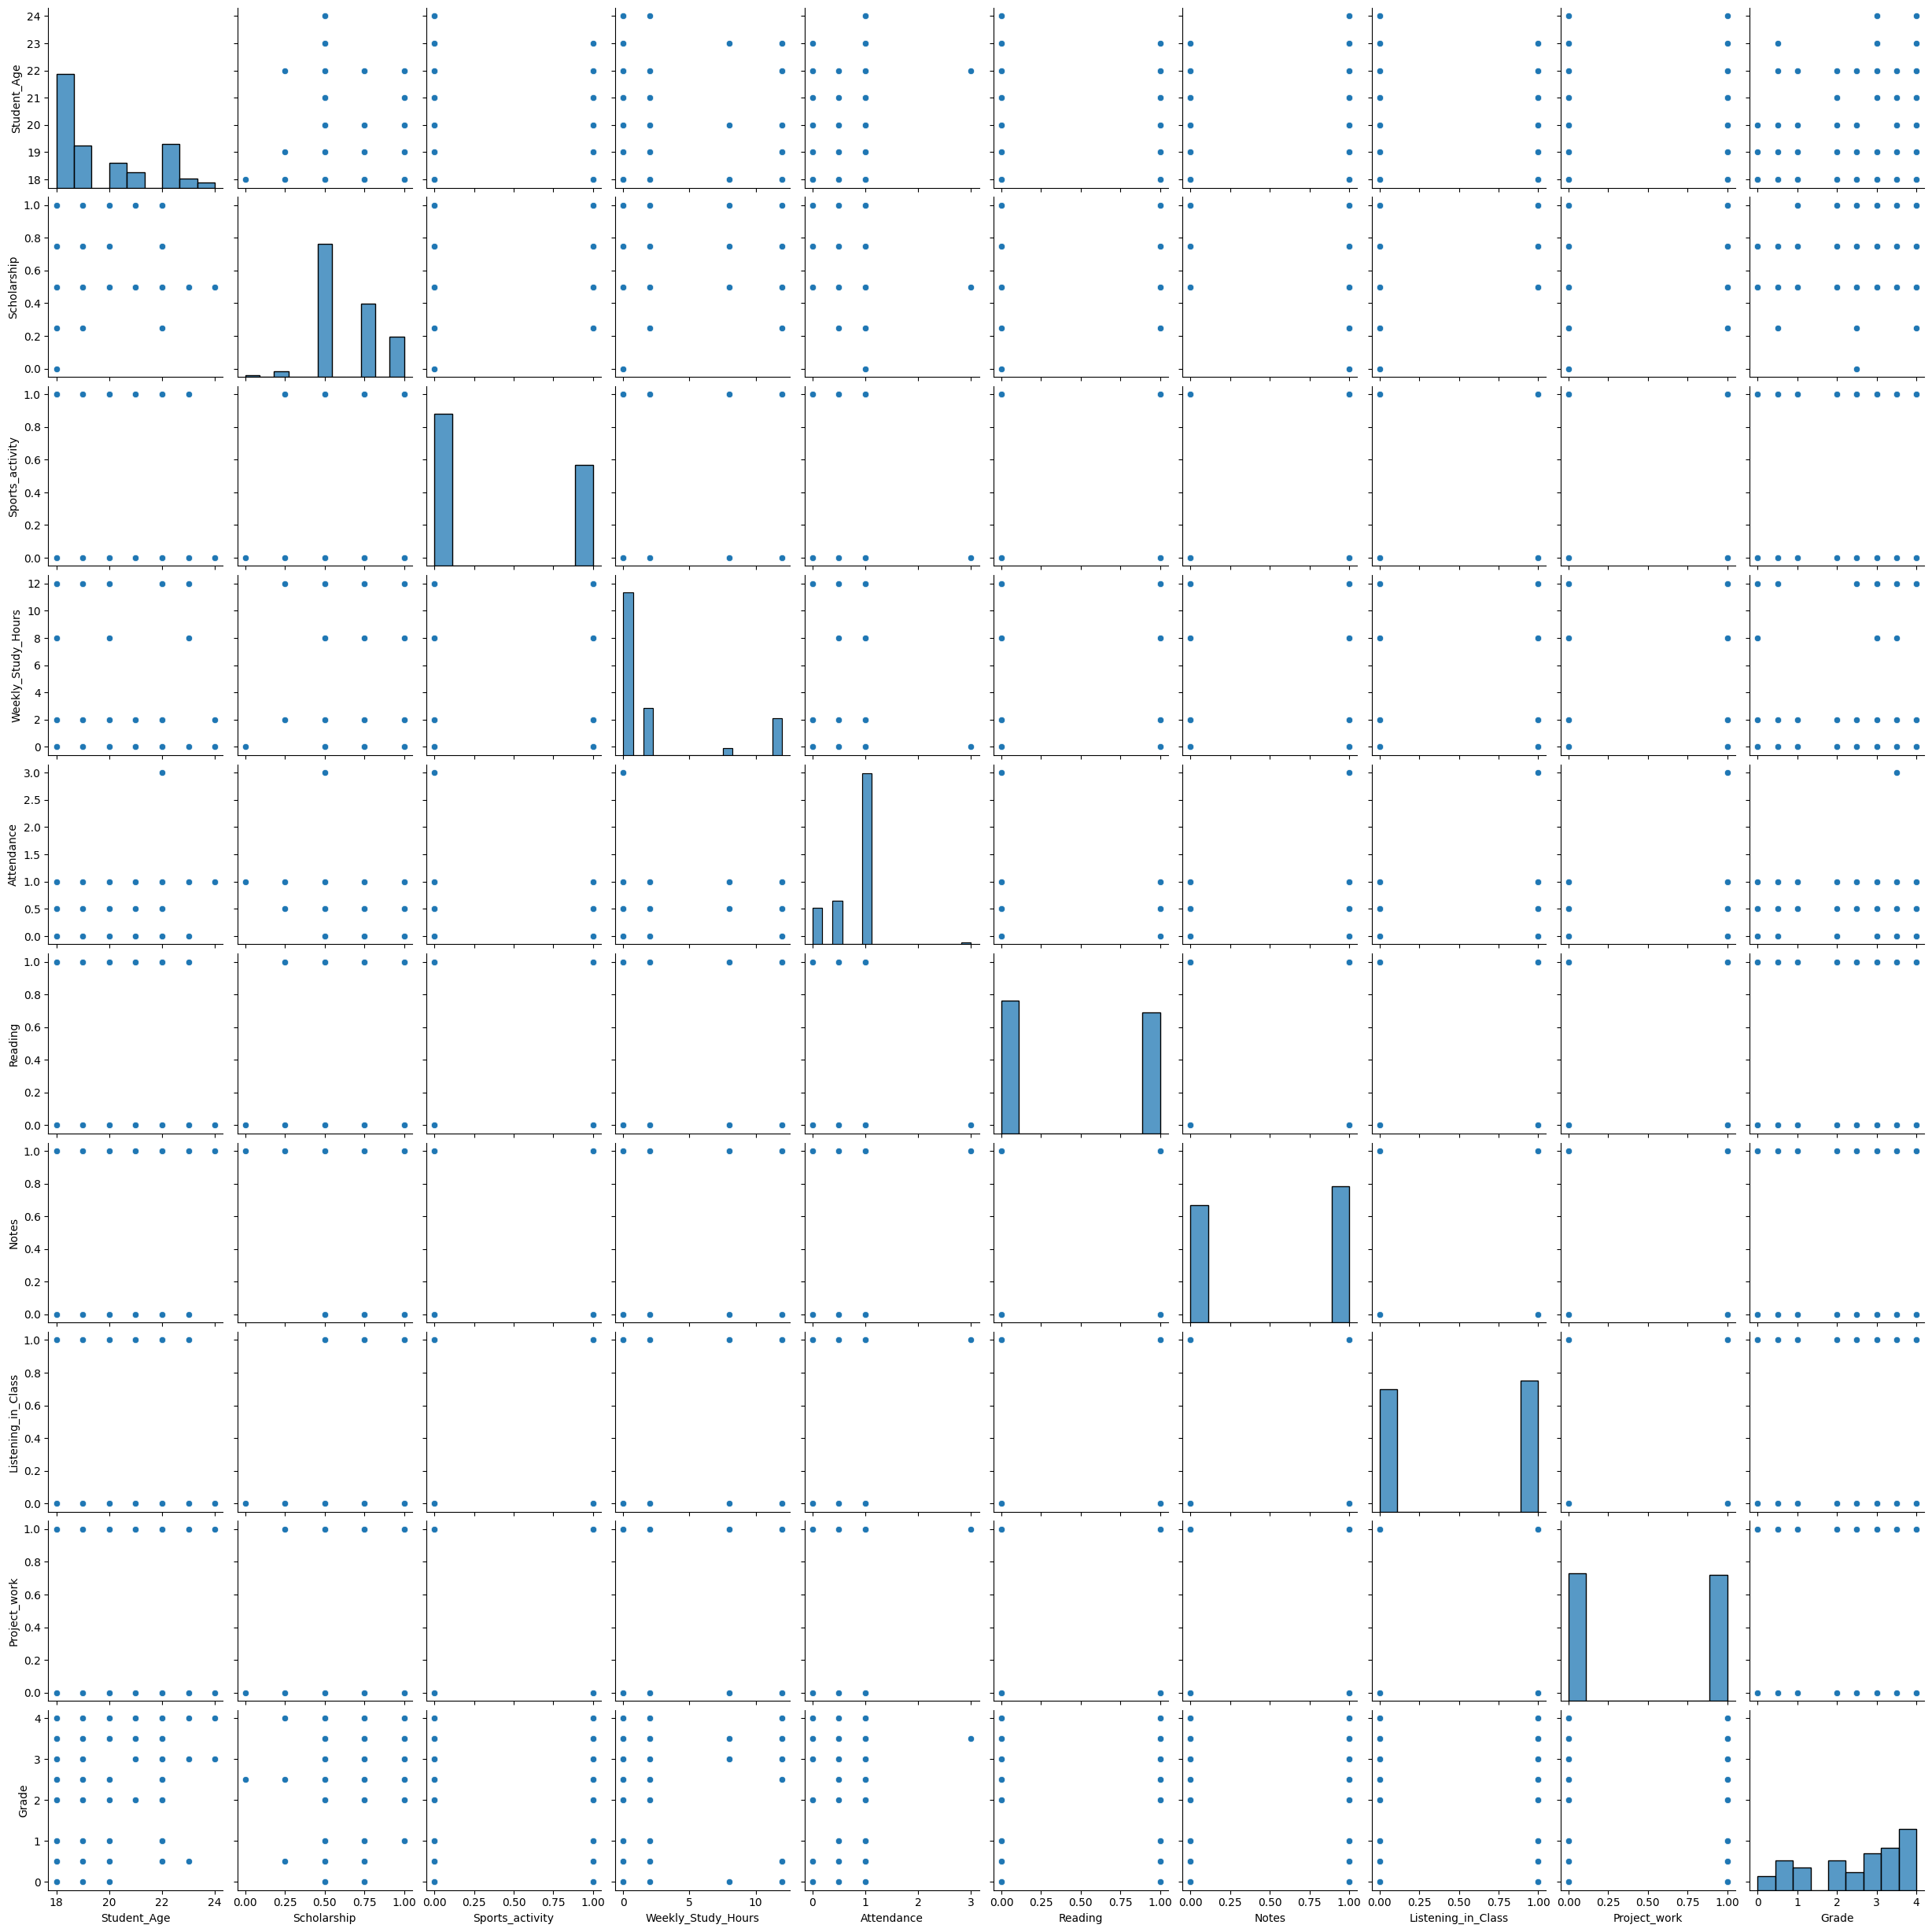

In [78]:
#Use Seaborn’s pairplot to create the big graphic containing all the different variables plotted against each other.
sns.pairplot(df)

In [79]:
#Create a list of independent variables and using loop to create a plot of each one against your dependent variable
y = df['Grade']
# xvars = ['Student_Age', 'Scholarship', 'Additional_Work', 'Sports_activity', 
#                      'Transportation', 'Weekly_Study_Hours', 'Attendance', 'Reading', 
#                      'Notes', 'Listening_in_Class', 'Project_work']

xvars = ['Student_Age','Scholarship','Sports_activity','Weekly_Study_Hours', 'Attendance', 'Reading', 'Notes', 'Listening_in_Class','Project_work']
X = df[xvars]

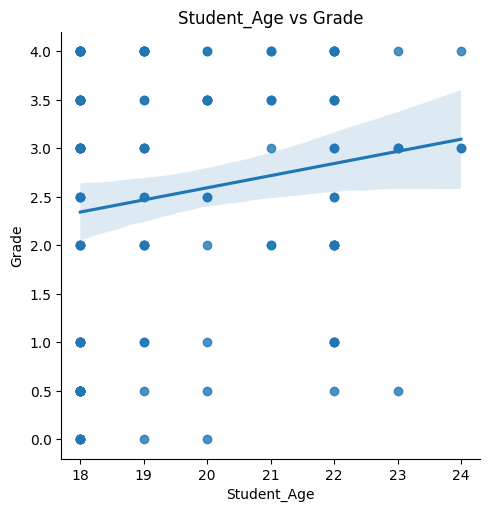

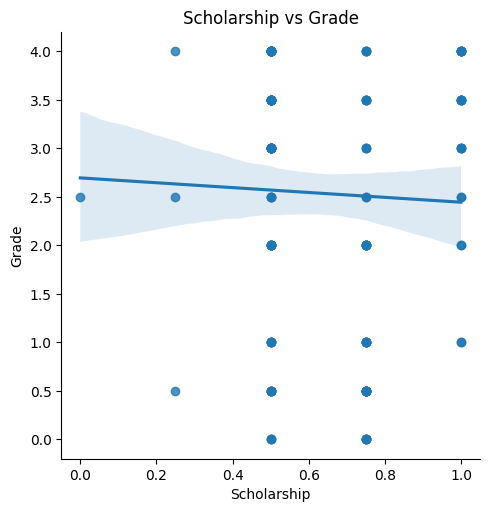

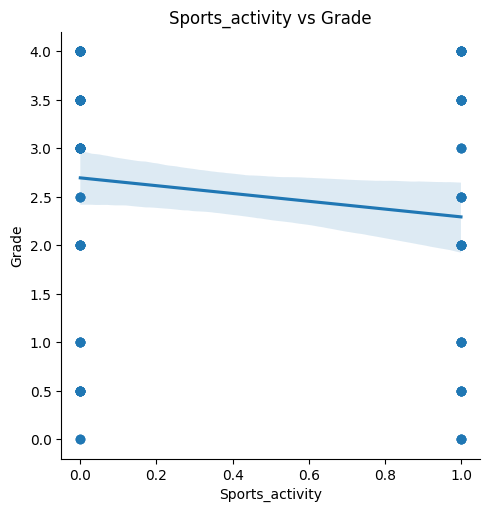

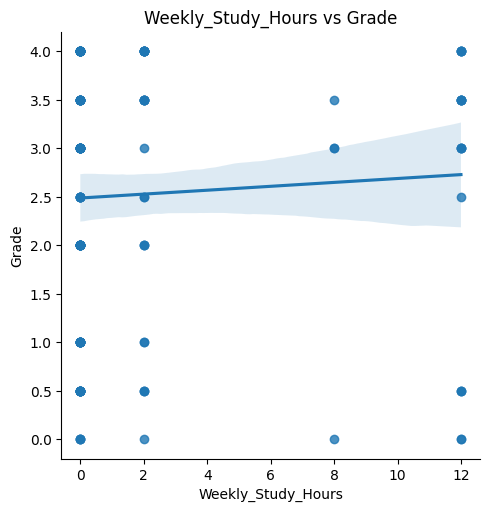

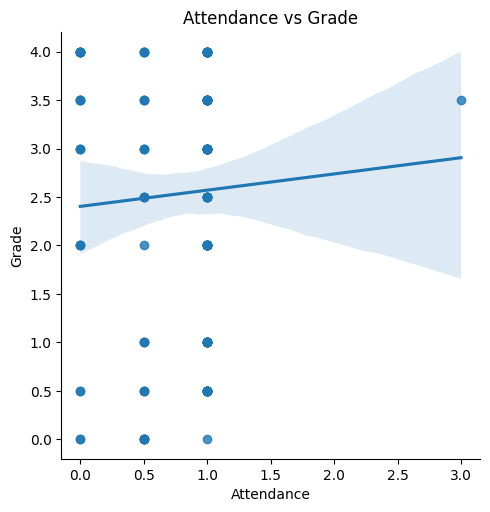

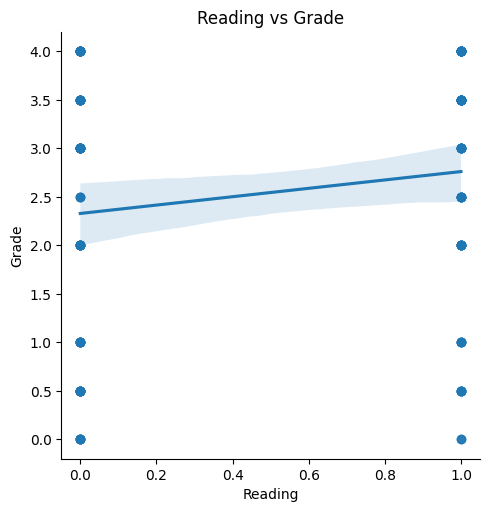

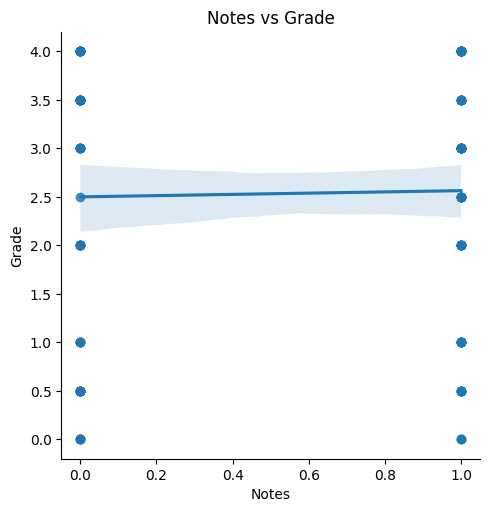

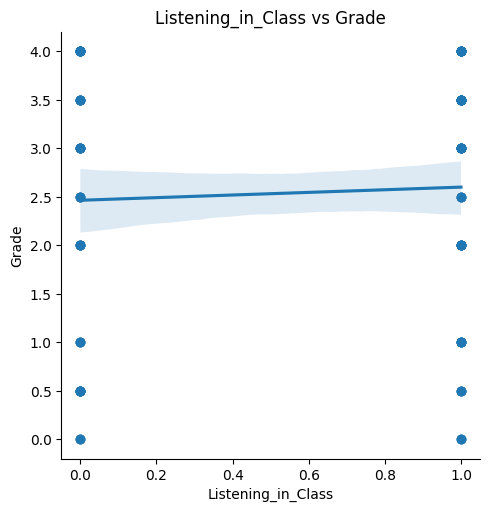

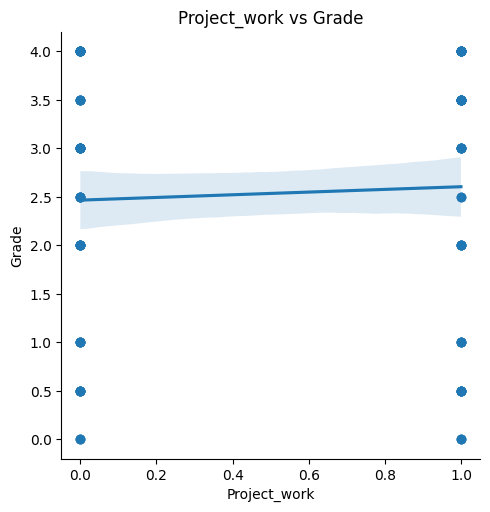

In [80]:
#Plot each independent variable against the dependent variable
# Loop through independent variables and create plots against 'Grade'

for i in xvars:
    sns.lmplot(x=i, y='Grade', fit_reg=True, data=df)
    plt.title(f'{i} vs Grade')
    plt.show()

In [87]:
#Create three different linear regression models using different subsets of independent variables.Print the regression results for each.
model1 = sm.OLS.from_formula('Grade ~ Weekly_Study_Hours+Attendance', df)
results1 = model1.fit()
results1.summary()

model2 = sm.OLS.from_formula('Grade ~ Attendance', df)
results2 = model2.fit()
results2.summary()

model3 = sm.OLS.from_formula('Grade ~ Weekly_Study_Hours+Project_work', df)
results3 = model3.fit()
results3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Grade   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.5009
Date:                Sun, 15 Dec 2024   Prob (F-statistic):              0.607
Time:                        14:51:13   Log-Likelihood:                -247.38
No. Observations:                 145   AIC:                             500.8
Df Residuals:                     142   BIC:                             509.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.4139      0.171     14.130      0.000       2.076       2.752
Weekly_Study_Hours     0.0208      0.026      0.787      0.433      -0.031       0.073
Project_work           0.1452      0.224      0.649      0.518      -0.297       0.588
==============================================================================
Omnibus:                       31.602   Durbin-Watson:                   1.030
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               14.108
Skew:                          -0.572   Prob(JB):                     0.000864
Kurtosis:                       1.988   Cond. No.                         11.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""